In [3]:
#pip install nibabel numpy matplotlib scikit-image -q

In [4]:
import os
import numpy as np
import nibabel as nib
import glob
from skimage.transform import resize
from scipy import interpolate
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [ ]:
DRIVE_FOLDER = 'D:/DL_images'
SAVE_DIR     = 'D:/DL_slices'

nii_files = sorted(
    glob.glob(os.path.join(DRIVE_FOLDER, '*.nii')) +
    glob.glob(os.path.join(DRIVE_FOLDER, '*.nii.gz'))
)

print(f"Found {len(nii_files)} NIfTI files in {DRIVE_FOLDER}")
for f in nii_files[:5]:
    print(f"  {os.path.basename(f)}")
if len(nii_files) > 5:
    print(f"  ... and {len(nii_files)-5} more")

Found 581 NIfTI files in D:/DL_images
  IXI002-Guys-0828-MPRAGESEN_-s256_-0301-00003-000001-01.nii
  IXI012-HH-1211-3DBRAINIXMADisoTFE12_-s3T111_-0301-00003-000001-01.nii
  IXI013-HH-1212-IXIMADisoTFE12_-s3T111_-0301-00003-000001-01.nii
  IXI014-HH-1236-IXIMADisoTFE12_-s3T113_-0301-00003-000001-01.nii
  IXI015-HH-1258-IXIMADisoTFE12_-s3T115_-0301-00003-000001-01.nii
  ... and 576 more


In [6]:
TARGET_SIZE = (256, 256)

def resize_volume(vol):
    """Resize each axial slice to TARGET_SIZE (256x256)."""
    h, w, num_slices = vol.shape
    resized = np.zeros((TARGET_SIZE[0], TARGET_SIZE[1], num_slices), dtype=np.float32)
    for i in range(num_slices):
        resized[:, :, i] = resize(
            vol[:, :, i], TARGET_SIZE,
            mode='reflect', anti_aliasing=True, preserve_range=True
        )
    return resized

def normalize_volume(vol):
    v_min, v_max = vol.min(), vol.max()
    if v_max - v_min == 0:
        return vol.astype(np.float32)
    return ((vol - v_min) / (v_max - v_min)).astype(np.float32)

def load_and_preprocess(filepath):
    img    = nib.load(filepath)
    vol    = img.get_fdata()
    vol    = resize_volume(vol)
    vol    = normalize_volume(vol)       # shape: (256, 256, num_slices)
    slices = np.moveaxis(vol, -1, 0)     # shape: (num_slices, 256, 256)
    return slices

In [7]:
# Dataset + baseline helpers
def simulate_acquisition(slices, acceleration_factor=2):
    total          = len(slices)
    acquired_idx   = list(range(0, total, acceleration_factor))
    missing_idx    = [i for i in range(total) if i not in acquired_idx]
    return acquired_idx, missing_idx

def build_25D_dataset(slices, acceleration_factor=2):
    acquired_idx, _ = simulate_acquisition(slices, acceleration_factor)
    inputs, targets, meta = [], [], []
    for i in range(len(acquired_idx) - 1):
        left_idx, right_idx = acquired_idx[i], acquired_idx[i+1]
        for mid_idx in range(left_idx+1, right_idx):
            inputs.append(np.stack([slices[left_idx], slices[right_idx]], axis=0))
            targets.append(slices[mid_idx])
            meta.append({'left': left_idx, 'right': right_idx, 'target': mid_idx})
    return np.array(inputs), np.array(targets), meta

def linear_interpolation(slices, acceleration_factor=2):
    acquired_idx, _ = simulate_acquisition(slices, acceleration_factor)
    recon = slices.copy()
    for i in range(len(acquired_idx) - 1):
        left_idx, right_idx = acquired_idx[i], acquired_idx[i+1]
        between = list(range(left_idx+1, right_idx))
        for j, mid_idx in enumerate(between):
            t = (j+1) / (len(between)+1)
            recon[mid_idx] = (1-t)*slices[left_idx] + t*slices[right_idx]
    return recon

def spline_interpolation(slices, acceleration_factor=2, kind='cubic'):
    acquired_idx, missing_idx = simulate_acquisition(slices, acceleration_factor)
    H, W = slices.shape[1], slices.shape[2]
    acquired_data = slices[acquired_idx].reshape(len(acquired_idx), -1)
    f = interpolate.interp1d(
        acquired_idx, acquired_data, axis=0,
        kind=kind, fill_value='extrapolate'
    )
    recon = slices.copy()
    if missing_idx:
        predicted = np.clip(f(missing_idx), 0, 1)
        recon[missing_idx] = predicted.reshape(-1, H, W)
    return recon

def evaluate_reconstruction(original, reconstructed, missing_indices):
    psnr_scores, ssim_scores = [], []
    for idx in missing_indices:
        orig  = original[idx]
        recon = np.clip(reconstructed[idx], 0, 1)
        if np.allclose(orig, recon):
            continue
        psnr_scores.append(psnr(orig, recon, data_range=1.0))
        ssim_scores.append(ssim(orig, recon, data_range=1.0))
    return {
        'psnr_mean': np.mean(psnr_scores) if psnr_scores else float('nan'),
        'psnr_std' : np.std(psnr_scores)  if psnr_scores else float('nan'),
        'ssim_mean': np.mean(ssim_scores) if ssim_scores else float('nan'),
        'ssim_std' : np.std(ssim_scores)  if ssim_scores else float('nan'),
    }


In [ ]:
ACCELERATION_FACTOR = 2
os.makedirs(SAVE_DIR, exist_ok=True)

all_inputs,  all_targets  = [], []
all_metrics_linear, all_metrics_spline = [], []
failed_files = []

print(f"Processing {len(nii_files)} files...\n")

for file_idx, filepath in enumerate(nii_files):
    fname = os.path.basename(filepath)
    try:
        # 1. Load & preprocess
        slices = load_and_preprocess(filepath)   # (N, 256, 256)

        # 2. Build 2.5D pairs
        inputs, targets, _ = build_25D_dataset(slices, ACCELERATION_FACTOR)
        all_inputs.append(inputs)
        all_targets.append(targets)

        # 3. Baselines
        _, missing_idx  = simulate_acquisition(slices, ACCELERATION_FACTOR)
        recon_lin       = linear_interpolation(slices, ACCELERATION_FACTOR)
        recon_spl       = spline_interpolation(slices, ACCELERATION_FACTOR)
        m_lin           = evaluate_reconstruction(slices, recon_lin, missing_idx)
        m_spl           = evaluate_reconstruction(slices, recon_spl, missing_idx)
        all_metrics_linear.append(m_lin)
        all_metrics_spline.append(m_spl)

        print(f"[{file_idx+1:>3}/{len(nii_files)}] {fname:<55} "
              f"slices={len(slices):>3}  "
              f"pairs={len(inputs):>4}  "
              f"PSNR_lin={m_lin['psnr_mean']:.2f}dB  "
              f"PSNR_spl={m_spl['psnr_mean']:.2f}dB")

    except Exception as e:
        print(f"[{file_idx+1:>3}/{len(nii_files)}] FAILED: {fname} — {e}")
        failed_files.append(filepath)

print(f"\nDone. Failed: {len(failed_files)} files.")

Processing 581 files...

[  1/581] IXI002-Guys-0828-MPRAGESEN_-s256_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=31.39dB  PSNR_spl=31.27dB
[  2/581] IXI012-HH-1211-3DBRAINIXMADisoTFE12_-s3T111_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=33.81dB  PSNR_spl=33.78dB
[  3/581] IXI013-HH-1212-IXIMADisoTFE12_-s3T111_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=34.94dB  PSNR_spl=35.06dB
[  4/581] IXI014-HH-1236-IXIMADisoTFE12_-s3T113_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=36.20dB  PSNR_spl=36.36dB
[  5/581] IXI015-HH-1258-IXIMADisoTFE12_-s3T115_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=35.23dB  PSNR_spl=35.24dB
[  6/581] IXI016-Guys-0697-IXI3DMPRAG_-s231_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=29.40dB  PSNR_spl=29.09dB
[  7/581] IXI017-Guys-0698-IXI3DMPRAG_-s231_-0301-00003-000001-01.nii slices=150  pairs=  74  PSNR_lin=31.45dB  PSNR_spl=31.49dB
[  8/581] IXI019-Guys-0702-IXI3DMPRAG_-s232_-0301-0

In [ ]:
dataset_inputs  = np.concatenate(all_inputs,  axis=0)  # (total_pairs, 2, 256, 256)
dataset_targets = np.concatenate(all_targets, axis=0)  # (total_pairs, 256, 256)

np.save(os.path.join(SAVE_DIR, 'dataset_inputs.npy'),  dataset_inputs)
np.save(os.path.join(SAVE_DIR, 'dataset_targets.npy'), dataset_targets)

print(f"Dataset saved to {SAVE_DIR}")
print(f"  dataset_inputs.npy  : {dataset_inputs.shape}")
print(f"  dataset_targets.npy : {dataset_targets.shape}")
print(f"  Total (input, target) pairs: {len(dataset_inputs):,}")

Dataset saved to D:/DL_slices
  dataset_inputs.npy  : (42816, 2, 256, 256)
  dataset_targets.npy : (42816, 256, 256)
  Total (input, target) pairs: 42,816


dataset_inputs.npy — shape (N, 2, 256, 256)

Each entry is a pair of neighboring acquired slices that bracket a missing slice. The 2 means two slices are stacked together:

dataset_inputs[0]  → [slice_1, slice_3]   # left and right neighbors

dataset_inputs[1]  → [slice_3, slice_5]   # next pair

dataset_inputs[2]  → [slice_5, slice_7]   # etc.

...

dataset_inputs[N]  → [slice_left, slice_right]

Think of it as: "given these two slices, predict what's between them"

dataset_targets.npy — shape (N, 256, 256)

Each entry is the ground truth missing slice that the model should learn to reconstruct:

dataset_targets[0]  → slice_2   # what sits between slice_1 and slice_3

dataset_targets[1]  → slice_4   # what sits between slice_3 and slice_5

dataset_targets[2]  → slice_6   # etc.

In [10]:
def aggregate_metrics(metrics_list):
    psnr_means = [m['psnr_mean'] for m in metrics_list if not np.isnan(m['psnr_mean'])]
    ssim_means = [m['ssim_mean'] for m in metrics_list if not np.isnan(m['ssim_mean'])]
    return {
        'psnr_mean': np.mean(psnr_means), 'psnr_std': np.std(psnr_means),
        'ssim_mean': np.mean(ssim_means), 'ssim_std': np.std(ssim_means),
        'per_scan_psnr': psnr_means,
        'per_scan_ssim': ssim_means,
    }

agg_lin = aggregate_metrics(all_metrics_linear)
agg_spl = aggregate_metrics(all_metrics_spline)

print("\n========== AGGREGATE BASELINE (all scans, ×2) ==========")
print(f"{'Method':<20} {'PSNR (dB)':>14} {'SSIM':>14}")
print("-" * 50)
print(f"{'Linear Interp.':<20} {agg_lin['psnr_mean']:>8.2f} ± {agg_lin['psnr_std']:.2f}"
      f"  {agg_lin['ssim_mean']:>6.4f} ± {agg_lin['ssim_std']:.4f}")
print(f"{'Cubic Spline':<20} {agg_spl['psnr_mean']:>8.2f} ± {agg_spl['psnr_std']:.2f}"
      f"  {agg_spl['ssim_mean']:>6.4f} ± {agg_spl['ssim_std']:.4f}")


========== AGGREGATE BASELINE (all scans, ×2) ==========
Method                    PSNR (dB)           SSIM
--------------------------------------------------
Linear Interp.          33.21 ± 2.98  0.9066 ± 0.0285
Cubic Spline            33.19 ± 3.16  0.9048 ± 0.0303


PSNR interpretation for medical images:

\> 40 dB — excellent, near-indistinguishable from original

35–40 dB — very good, minor imperceptible differences

30–35 dB — acceptable, slight visible blurring

< 30 dB — noticeable degradation, diagnostically risky

SSIM interpretation (0 to 1):

\> 0.95 — excellent structural preservation

0.90–0.95 — good, subtle loss

0.85–0.90 — moderate, some structural blurring

< 0.85 — meaningful structural loss

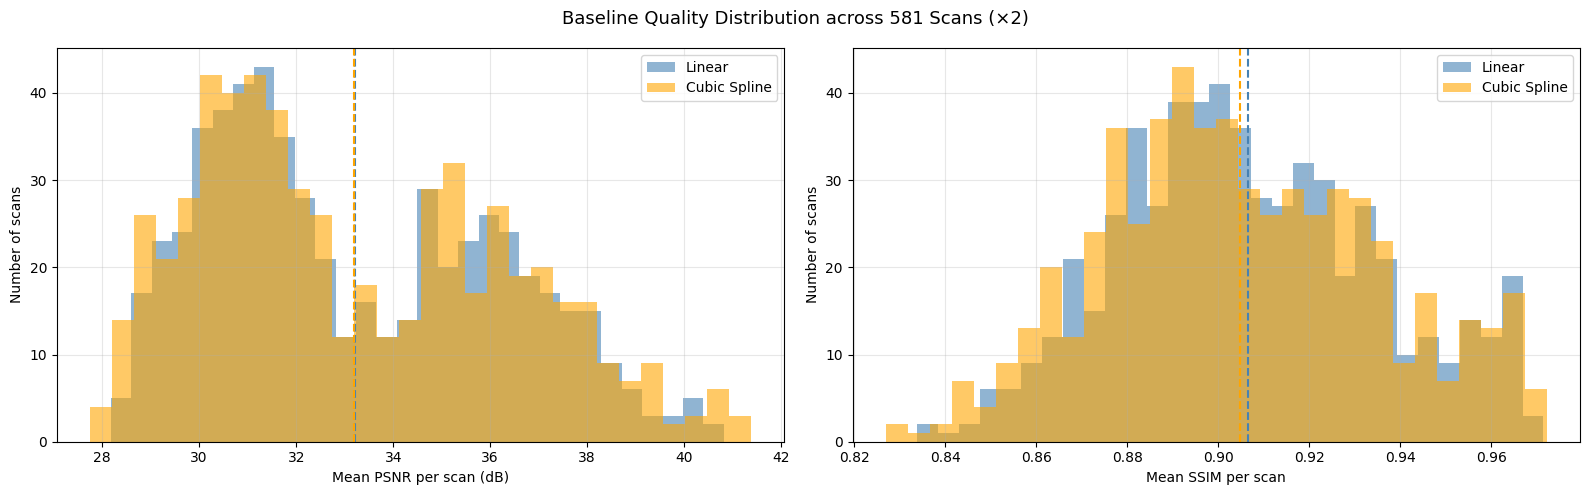

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"Baseline Quality Distribution across {len(nii_files)} Scans (×2)", fontsize=13)

for ax, (lin, spl, metric) in zip(axes, [
    (agg_lin['per_scan_psnr'], agg_spl['per_scan_psnr'], 'Mean PSNR per scan (dB)'),
    (agg_lin['per_scan_ssim'], agg_spl['per_scan_ssim'], 'Mean SSIM per scan'),
]):
    ax.hist(lin, bins=30, alpha=0.6, label='Linear',       color='steelblue')
    ax.hist(spl, bins=30, alpha=0.6, label='Cubic Spline', color='orange')
    ax.axvline(np.mean(lin), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(spl), color='orange',    linestyle='--', linewidth=1.5)
    ax.set_xlabel(metric)
    ax.set_ylabel('Number of scans')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The bimodal (two-hump) shape is the most important feature
Both PSNR and SSIM histograms show two distinct peaks, meaning your 581 scans naturally fall into two groups:

Left hump (28–32 dB / 0.84–0.89 SSIM) — harder scans to interpolate, likely from a different scanner, protocol, or brain region with more complex anatomy
Right hump (33–41 dB / 0.90–0.97 SSIM) — easier scans, probably more uniform tissue or simpler contrast profiles

This is actually a significant finding — your dataset is not homogeneous. The IXI dataset comes from 3 different hospitals (Guys, Hammersmith, IOP) with different scanners, which almost certainly explains the two clusters.

Linear vs Cubic Spline are nearly identical
The blue and orange bars overlap almost perfectly throughout — confirming what you saw with the single scan. At ×2 acceleration the two methods are essentially equivalent across all 581 scans.

The dashed vertical lines (means) sit in the valley between the two humps
This is a classic problem with bimodal distributions — the mean (~32–33 dB) doesn't actually represent either group well. It falls in the least populated region. This means reporting a single mean PSNR for your whole dataset is misleading, and you should consider reporting results separately per hospital/scanner group.

In [14]:
np.save(os.path.join(SAVE_DIR, 'baseline_metrics_linear.npy'), all_metrics_linear)
np.save(os.path.join(SAVE_DIR, 'baseline_metrics_spline.npy'), all_metrics_spline)

print(f"\nAll outputs in: {SAVE_DIR}")
print(f"  dataset_inputs.npy          {dataset_inputs.shape}")
print(f"  dataset_targets.npy         {dataset_targets.shape}")
print(f"  baseline_metrics_linear.npy")
print(f"  baseline_metrics_spline.npy")
if failed_files:
    print(f"\n  ⚠ {len(failed_files)} files failed — check failed_files list")


All outputs in: D:/DL_slices
  dataset_inputs.npy          (42816, 2, 256, 256)
  dataset_targets.npy         (42816, 256, 256)
  baseline_metrics_linear.npy
  baseline_metrics_spline.npy


inputs shape  : (42816, 2, 256, 256)
targets shape : (42816, 256, 256)
Total pairs   : 42,816


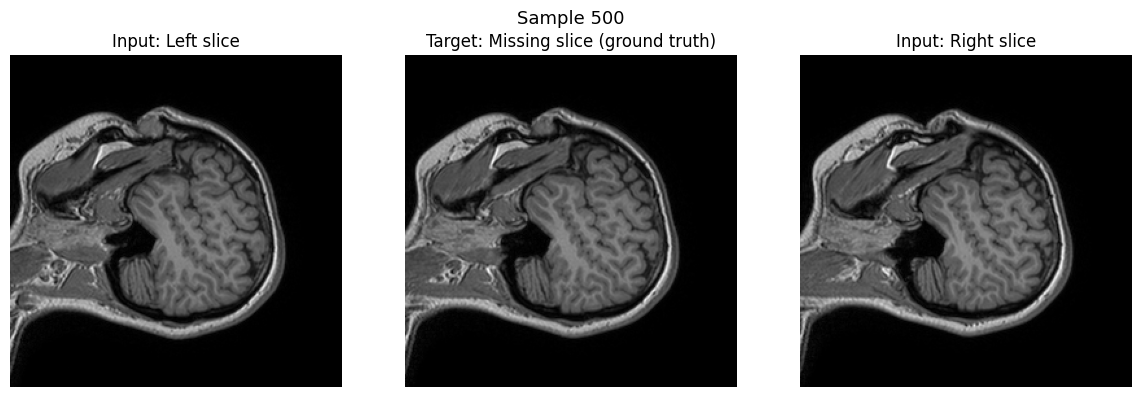

In [15]:
inputs  = np.load('D:/DL_slices/dataset_inputs.npy')
targets = np.load('D:/DL_slices/dataset_targets.npy')

print(f"inputs shape  : {inputs.shape}")   # (N, 2, 256, 256)
print(f"targets shape : {targets.shape}")  # (N, 256, 256)
print(f"Total pairs   : {len(inputs):,}")

# Visualize sample i
i = 500  # change this to any index

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f"Sample {i}", fontsize=13)

axes[0].imshow(inputs[i][0],  cmap='gray')
axes[0].set_title("Input: Left slice")

axes[1].imshow(targets[i],    cmap='gray')
axes[1].set_title("Target: Missing slice (ground truth)")

axes[2].imshow(inputs[i][1],  cmap='gray')
axes[2].set_title("Input: Right slice")

for ax in axes:
    ax.axis('off')
plt.tight_layout()